# Análisis de datos — Pregunta 1

## Pregunta de negocio

¿Qué tan dependiente es la Agencia Logística de un grupo reducido de proveedores, y en qué modalidades de contratación se concentra ese riesgo?



In [20]:
#%pip install matplotlib
#%pip install seaborn

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [22]:
base = pd.read_csv("base_analitica.csv")

proveedores = pd.read_csv(
    "resumen_proveedores.csv"
)

proveedores_modalidad = pd.read_csv(
    "proveedores_modalidad.csv"
)

In [23]:
print("Contratos:", base.shape)
print("Proveedores:", proveedores.shape)
print(
    "Proveedores por modalidad:",
    proveedores_modalidad.shape
)

print("\nTotal de proveedores:")
print(proveedores["id_proveedor"].nunique())

print("\nTotal contratado:")
print(
    f"${base['valor_del_contrato'].sum():,.0f}"
)

Contratos: (7325, 93)
Proveedores: (1945, 8)
Proveedores por modalidad: (2377, 8)

Total de proveedores:
1945

Total contratado:
$5,284,197,142,982


## 1. Concentración general de proveedores

Primero se analiza qué porcentaje del valor total contratado está concentrado en los proveedores principales.

In [24]:
# Participación del proveedor principal
cr1 = proveedores.head(1)["participacion"].sum() * 100

# Participación de los 5 proveedores principales
cr5 = proveedores.head(5)["participacion"].sum() * 100

# Participación de los 10 proveedores principales
cr10 = proveedores.head(10)["participacion"].sum() * 100

# Índice de concentración HHI
hhi = (
    proveedores["participacion"] ** 2
).sum() * 10000

# Proveedores necesarios para alcanzar el 80 % del valor
proveedores_80 = (
    proveedores["participacion_acumulada"] < 0.80
).sum() + 1

print("Número total de proveedores:", len(proveedores))
print(f"Participación del proveedor principal: {cr1:.2f}%")
print(f"Participación de los 5 principales: {cr5:.2f}%")
print(f"Participación de los 10 principales: {cr10:.2f}%")
print(f"Índice HHI: {hhi:.2f}")
print(
    "Proveedores necesarios para alcanzar el 80%:",
    proveedores_80
)

Número total de proveedores: 1945
Participación del proveedor principal: 12.99%
Participación de los 5 principales: 38.48%
Participación de los 10 principales: 54.11%
Índice HHI: 417.00
Proveedores necesarios para alcanzar el 80%: 41


la concentración general es relativamente baja. No existe un único proveedor que domine la mayoría del valor.
Aunque la Agencia tiene una gran cantidad de proveedores y presenta un HHI global bajo, los diez proveedores principales reúnen más de la mitad del valor contratado. Esto muestra una concentración importante en un grupo reducido, aunque sin que un solo proveedor domine por completo la contratación.

## 2. Concentración de proveedores por modalidad

Se calculan el HHI y las participaciones de los principales proveedores dentro de cada modalidad de contratación.

In [25]:
resultados = []

# Repetir el cálculo para cada modalidad
for modalidad in proveedores_modalidad[
    "modalidad_de_contratacion"
].unique():

    datos = proveedores_modalidad[
        proveedores_modalidad[
            "modalidad_de_contratacion"
        ] == modalidad
    ].sort_values(
        "participacion_modalidad",
        ascending=False
    )

    hhi_modalidad = (
        datos["participacion_modalidad"] ** 2
    ).sum() * 10000

    cr1_modalidad = (
        datos.head(1)["participacion_modalidad"].sum() * 100
    )

    cr5_modalidad = (
        datos.head(5)["participacion_modalidad"].sum() * 100
    )

    cr10_modalidad = (
        datos.head(10)["participacion_modalidad"].sum() * 100
    )

    resultados.append({
        "modalidad": modalidad,
        "numero_proveedores": len(datos),
        "numero_contratos": datos["numero_contratos"].sum(),
        "valor_total": datos["valor_total"].sum(),
        "hhi": hhi_modalidad,
        "cr1": cr1_modalidad,
        "cr5": cr5_modalidad,
        "cr10": cr10_modalidad
    })

resumen_modalidades = pd.DataFrame(resultados)

# Calcular el peso de cada modalidad sobre el total
resumen_modalidades["peso_total"] = (
    resumen_modalidades["valor_total"]
    / resumen_modalidades["valor_total"].sum()
    * 100
)

# Mostrar valores en millones
resumen_modalidades["valor_millones"] = (
    resumen_modalidades["valor_total"]
    / 1_000_000
)

# Organizar de mayor a menor valor
resumen_modalidades = resumen_modalidades.sort_values(
    "valor_total",
    ascending=False
).reset_index(drop=True)

resumen_modalidades[
    [
        "modalidad",
        "numero_proveedores",
        "numero_contratos",
        "valor_millones",
        "peso_total",
        "hhi",
        "cr1",
        "cr5",
        "cr10"
    ]
].round(2)

,modalidad,numero_proveedores,numero_contratos,valor_millones,peso_total,hhi,cr1,cr5,cr10
0,Contratación régimen especial,8,50,1921070.63,36.36,2168.61,35.74,90.66,100.00
1,Selección abreviada subasta inversa,363,1742,1742851.75,32.98,417.31,12.94,37.37,50.33
2,Licitación pública,41,63,960213.36,18.17,2238.87,41.49,82.07,92.16
3,Mínima cuantía,1351,4019,276619.70,5.23,1119.01,31.72,48.97,54.02
4,Selección Abreviada de Menor Cuantía,312,712,236119.30,4.47,207.25,8.09,24.84,36.58
5,Contratación directa,209,585,76520.09,1.45,1067.04,24.86,60.73,70.09
6,Contratación Directa (con ofertas),62,123,23853.63,0.45,2127.13,40.95,77.41,89.21
7,Licitación pública Obra Publica,5,5,21462.49,0.41,2573.50,34.97,100.00,100.00
8,Seleccion Abreviada Menor Cuantia Sin Manifest...,7,7,16584.70,0.31,4753.73,66.41,97.98,100.00
9,Concurso de méritos abierto,17,17,8863.32,0.17,2097.47,37.54,76.15,93.05


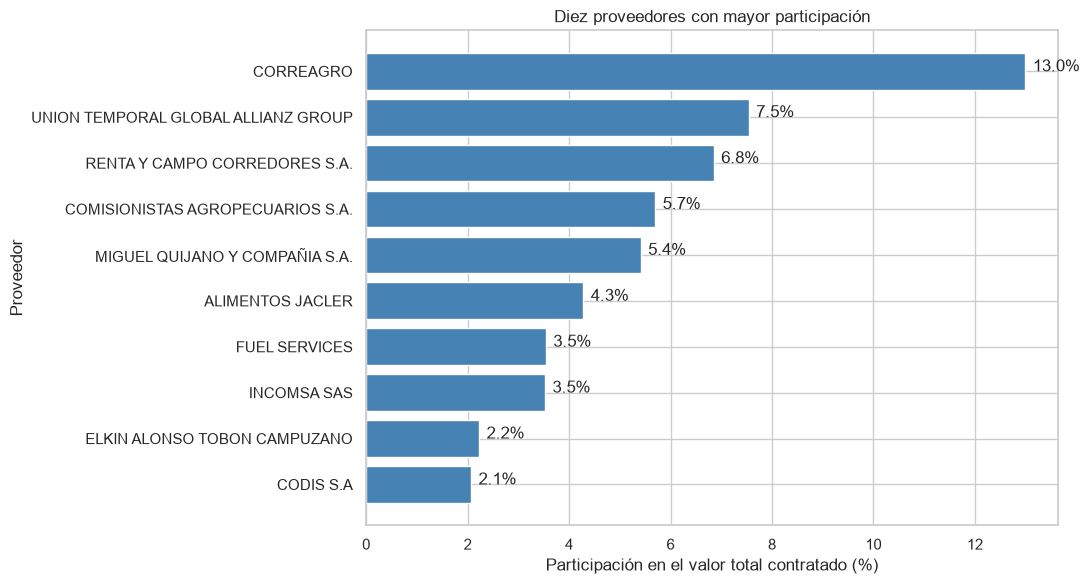

In [26]:
# Gráfico de los 10 proveedores con mayor participación

top10 = proveedores.head(10).sort_values(
    "participacion",
    ascending=True
)

porcentajes = top10["participacion"] * 100

plt.figure(figsize=(11, 6))

plt.barh(
    top10["proveedor"],
    porcentajes,
    color="steelblue"
)

# Mostrar el porcentaje en cada barra
for posicion, porcentaje in enumerate(porcentajes):
    plt.text(
        porcentaje + 0.15,
        posicion,
        f"{porcentaje:.1f}%"
    )

plt.xlabel("Participación en el valor total contratado (%)")
plt.ylabel("Proveedor")
plt.title("Diez proveedores con mayor participación")

plt.tight_layout()
plt.show()

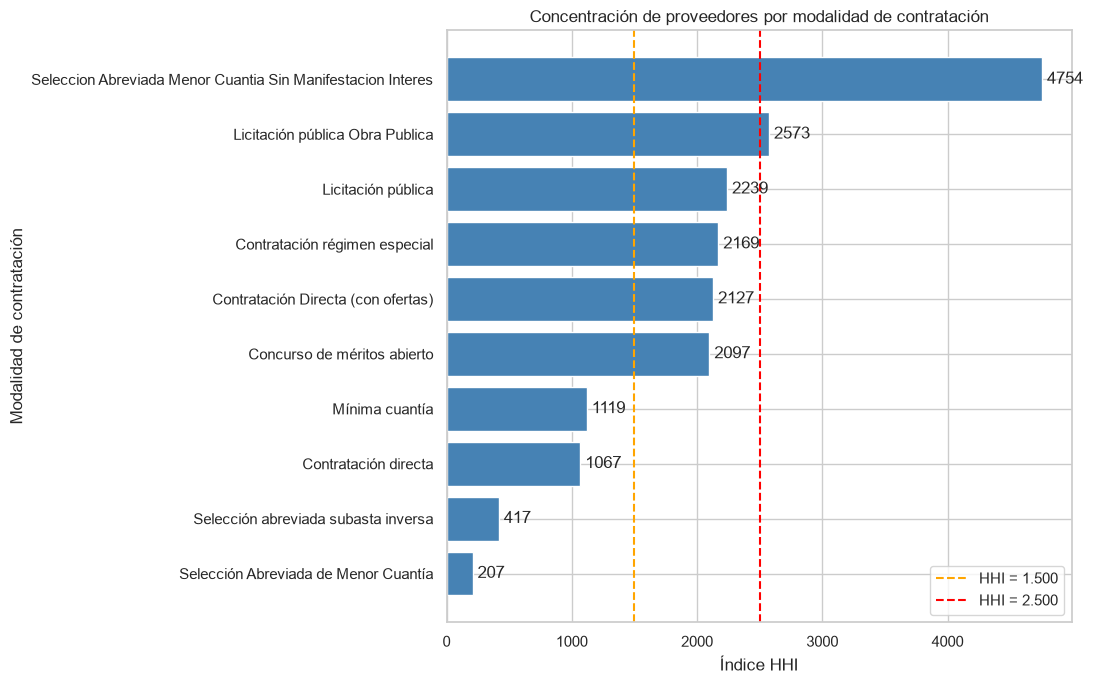

In [29]:
# HHI por modalidad excluyendo modalidades con un solo proveedor

hhi_grafica = resumen_modalidades[
    resumen_modalidades["numero_proveedores"] > 1
].sort_values(
    "hhi",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    hhi_grafica["modalidad"],
    hhi_grafica["hhi"],
    color="steelblue"
)

# Mostrar el valor HHI al final de cada barra
for posicion, valor in enumerate(hhi_grafica["hhi"]):
    plt.text(
        valor + 40,
        posicion,
        f"{valor:.0f}",
        va="center"
    )

# Líneas de referencia
plt.axvline(
    1500,
    color="orange",
    linestyle="--",
    label="HHI = 1.500"
)

plt.axvline(
    2500,
    color="red",
    linestyle="--",
    label="HHI = 2.500"
)

plt.xlabel("Índice HHI")
plt.ylabel("Modalidad de contratación")
plt.title("Concentración de proveedores por modalidad de contratación")

plt.legend()

plt.tight_layout()
plt.show()

3. HHI vs. peso de cada modalidad en la contratación

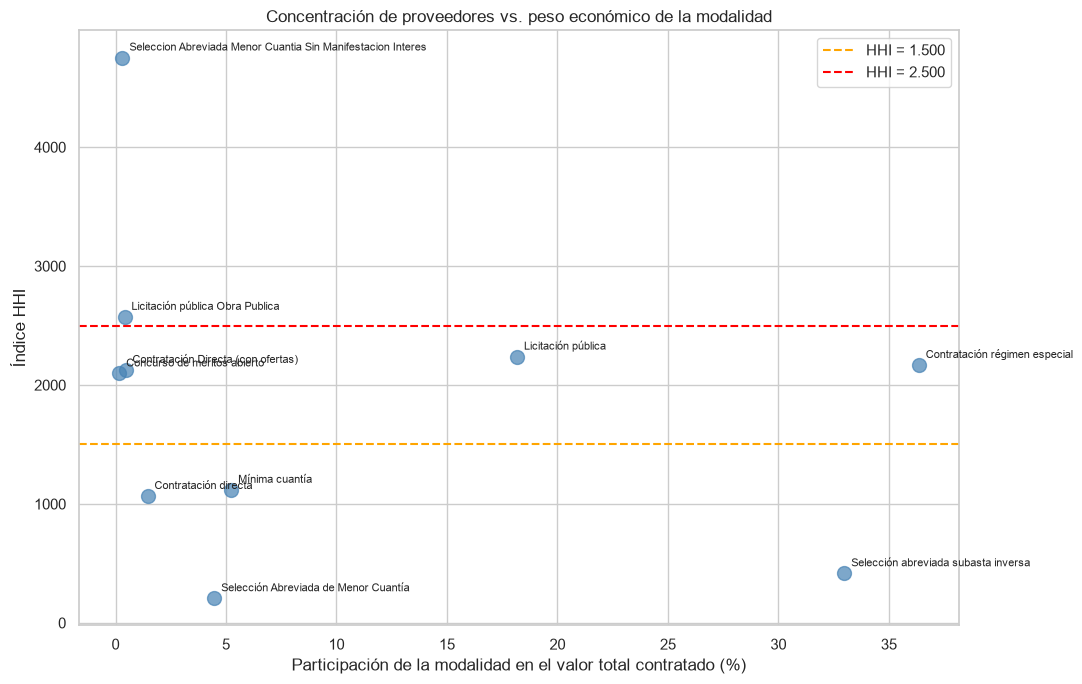

In [30]:
# Relación entre concentración y peso económico de cada modalidad

grafica_riesgo = resumen_modalidades[
    resumen_modalidades["numero_proveedores"] > 1
].copy()

plt.figure(figsize=(11, 7))

plt.scatter(
    grafica_riesgo["peso_total"],
    grafica_riesgo["hhi"],
    s=100,
    alpha=0.7,
    color="steelblue"
)


plt.axhline(
    1500,
    color="orange",
    linestyle="--",
    label="HHI = 1.500"
)

plt.axhline(
    2500,
    color="red",
    linestyle="--",
    label="HHI = 2.500"
)


for _, fila in grafica_riesgo.iterrows():
    plt.annotate(
        fila["modalidad"],
        (fila["peso_total"], fila["hhi"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Participación de la modalidad en el valor total contratado (%)")
plt.ylabel("Índice HHI")

plt.title(
    "Concentración de proveedores vs. peso económico de la modalidad"
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
Gráfica 4 — Concentración acumulada de proveedores

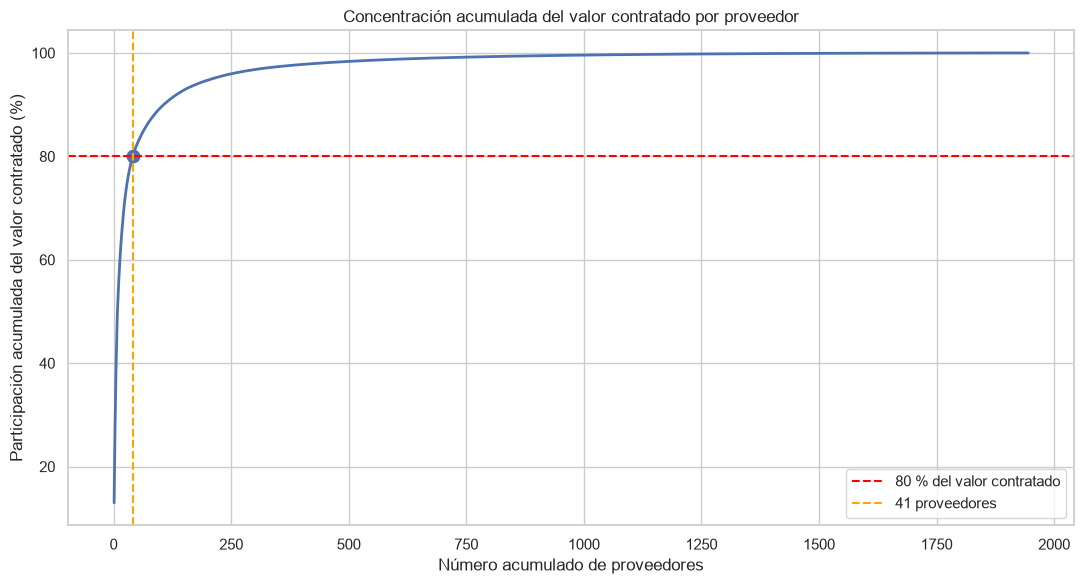

In [31]:
# Curva de concentración acumulada de proveedores

proveedores_grafica = (
    proveedores
    .sort_values("participacion", ascending=False)
    .reset_index(drop=True)
    .copy()
)


proveedores_grafica["ranking"] = (
    proveedores_grafica.index + 1
)


proveedores_grafica["participacion_acumulada_grafica"] = (
    proveedores_grafica["participacion"].cumsum() * 100
)


proveedores_80_grafica = (
    proveedores_grafica["participacion_acumulada_grafica"] < 80
).sum() + 1

plt.figure(figsize=(11, 6))

plt.plot(
    proveedores_grafica["ranking"],
    proveedores_grafica["participacion_acumulada_grafica"],
    linewidth=2
)


plt.axhline(
    80,
    color="red",
    linestyle="--",
    label="80 % del valor contratado"
)


plt.axvline(
    proveedores_80_grafica,
    color="orange",
    linestyle="--",
    label=f"{proveedores_80_grafica} proveedores"
)


plt.scatter(
    proveedores_80_grafica,
    80,
    s=80
)

plt.xlabel("Número acumulado de proveedores")
plt.ylabel("Participación acumulada del valor contratado (%)")

plt.title(
    "Concentración acumulada del valor contratado por proveedor"
)

plt.legend()

plt.tight_layout()
plt.show()